In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# # Convert string representation to actual list, checking for NaN values first
df['job_skills' ] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

import seaborn as sns

/opt/anaconda3/envs/python_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Filter for UK Data Analyst roles

In [2]:
# Only get data engineer jobs in the US
df_DA_UK = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United Kingdom')]


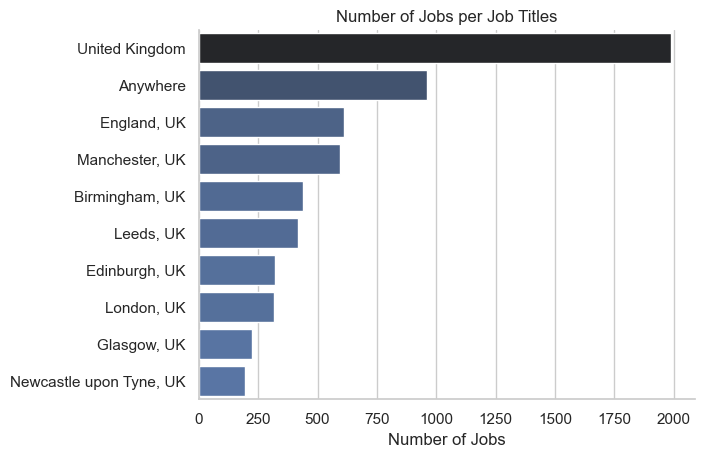

In [3]:
df_plot = df_DA_UK['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style="whitegrid")
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Number of Jobs per Job Titles')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


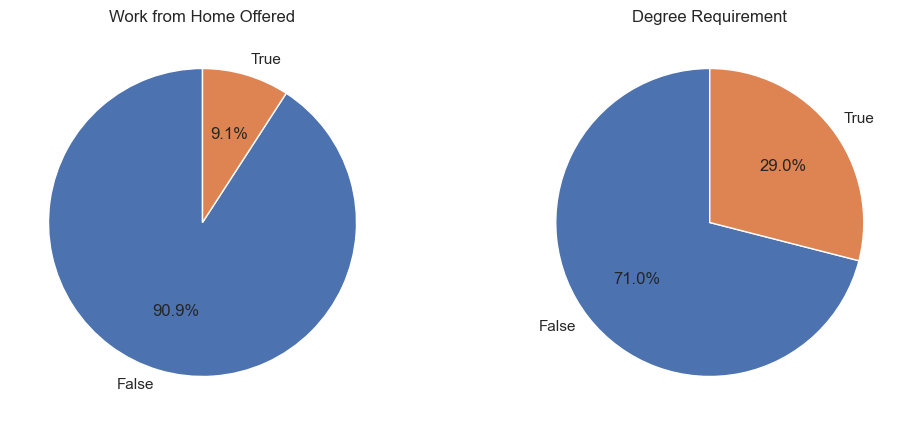

In [6]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement'
}

fig, ax = plt.subplots(1, 2)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_UK[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)
plt.show()

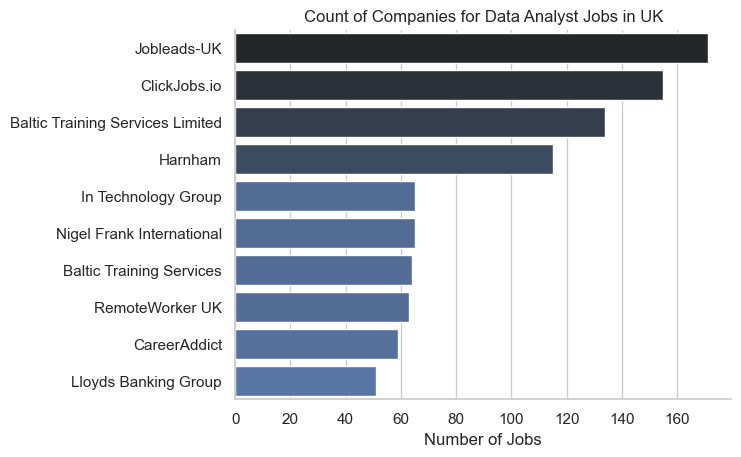

In [5]:
df_plot = df_DA_UK['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style="whitegrid")
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Count of Companies for Data Analyst Jobs in UK')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()